# LaBr3(Ce) (CH0)

In [73]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
from datetime import date

---

# Load data and get time

### background

#### 17/12

In [74]:
bg = {}

energy1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Energy_ch0.txt", skiprows=1)
timestamps1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Timestamp_ch0.txt", skiprows=1)

channels1 = energy1[:, 0]
counts1 = energy1[:, 1]
t1 = timestamps1[:, 0]
time1 = (t1[-1] - t1[0]) * 1e-12

bg["d"] = {
    "channels": channels1,
    "counts": counts1,
    "time": time1
}

#### 18/03

In [75]:
energy2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Energy_ch0.txt", skiprows=1)
timestamps2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Timestamp_ch0.txt", skiprows=1)

channels2 = energy2[:, 0]
counts2 = energy2[:, 1]
t2 = timestamps2[:, 0]
time2 = (t2[-1] - t2[0]) * 1e-12

bg["m"] = {
    "channels": channels2,
    "counts": counts2,
    "time": time2
}

### Na22

#### 17/12

In [76]:
na22d = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 Na22 pos{}"

for i in range(1, 10):
    path = base_path.format(i)
    
    energy = np.loadtxt(f"{path}\\Energy_ch0.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    channels = energy[:, 0]
    counts = energy[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22d[f"{i}"] = {
        "channels": channels,
        "counts": counts,
        "time": time
    }

#### 18/03

In [77]:
na22m = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_Na22Pos{}"

for i in range(1, 21):
    path = base_path.format(i)
    
    energy = np.loadtxt(f"{path}\\Energy_ch0.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    channels = energy[:, 0]
    counts = energy[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22m[f"{i}"] = {
        "channels": channels,
        "counts": counts,
        "time": time
    }

---

# Subtract background

### background

#### 17/12

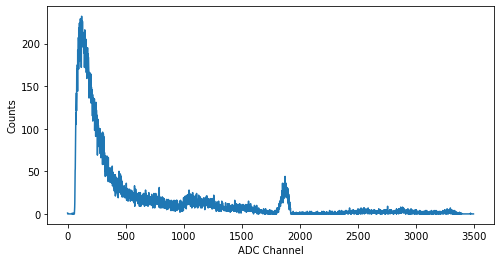

In [78]:
#spectrum background
range_bg = (bg["d"]["channels"] > 0) & (bg["d"]["channels"] < 3500)
plt.figure(figsize=(8, 4))
plt.plot(bg["d"]["channels"][range_bg], bg["d"]["counts"][range_bg])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

#### 18/03

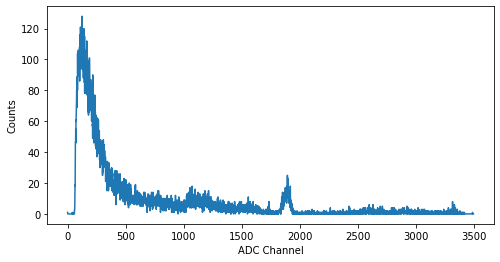

In [79]:
#spectrum background
range_bg = (bg["m"]["channels"] > 0) & (bg["m"]["channels"] < 3500)

plt.figure(figsize=(8, 4))
plt.plot(bg["m"]["channels"][range_bg], bg["m"]["counts"][range_bg])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

### Na22

#### 17/12

In [80]:
for key in na22d:
    counts_bg_na22 = bg["d"]["counts"] * (na22d[key]["time"] / bg["d"]["time"])
    na22d[key]["netcounts"] = na22d[key]["counts"] - counts_bg_na22
    na22d[key]["netcounts"][na22d[key]["netcounts"] < 0] = 0

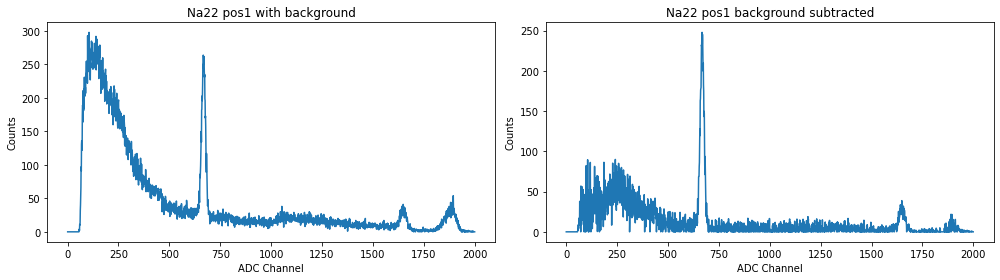

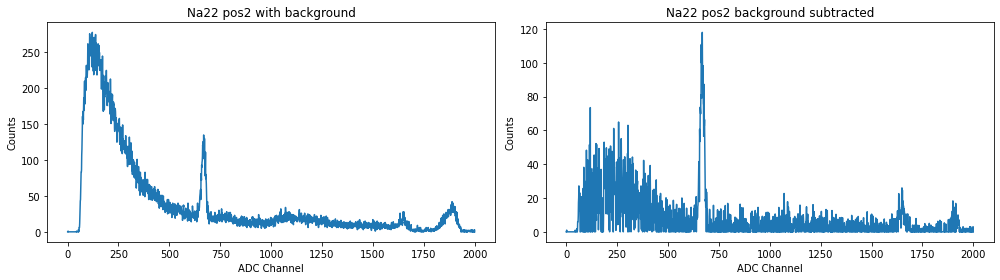

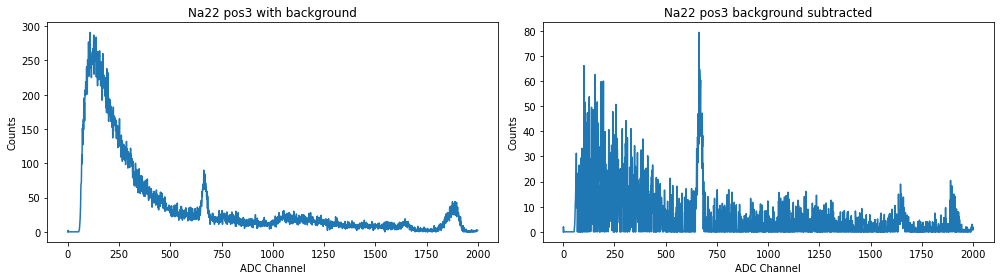

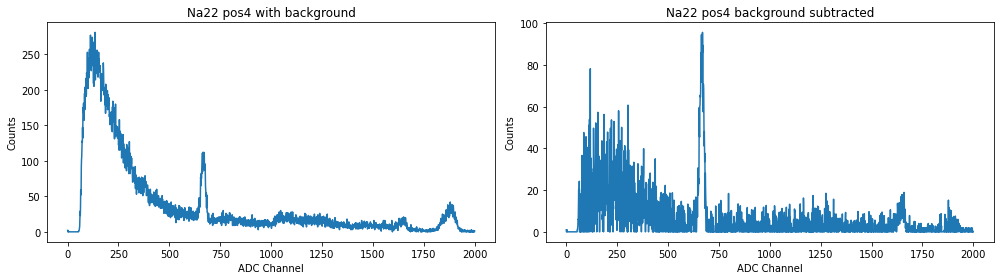

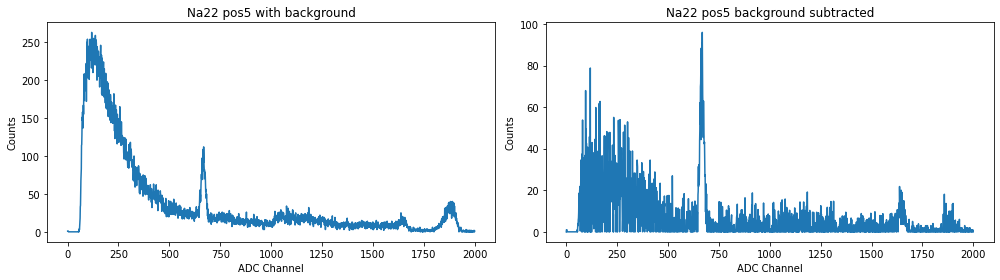

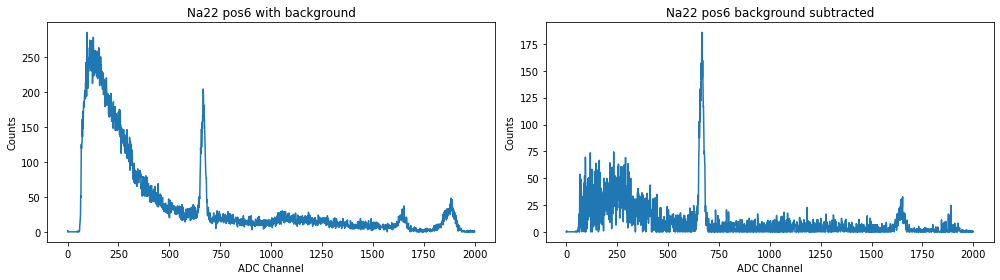

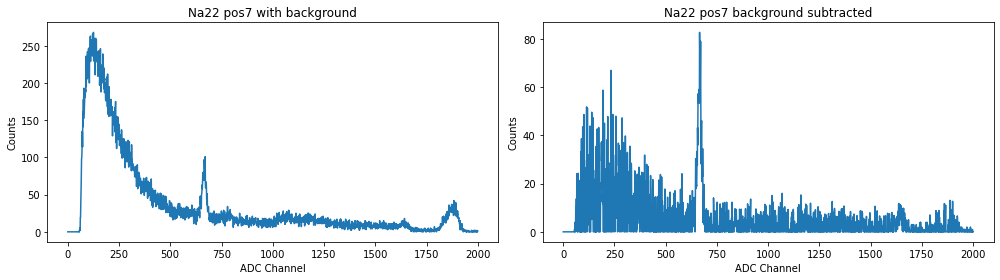

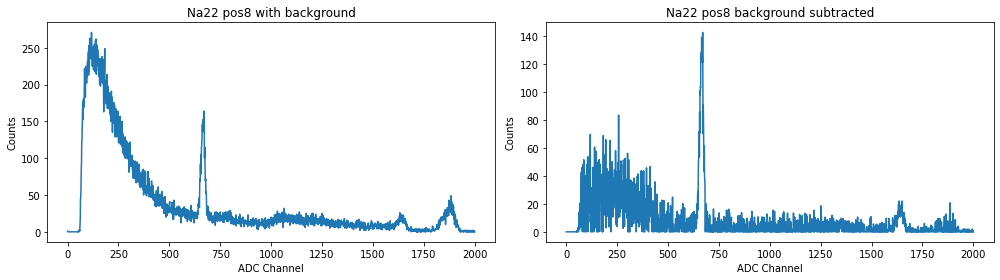

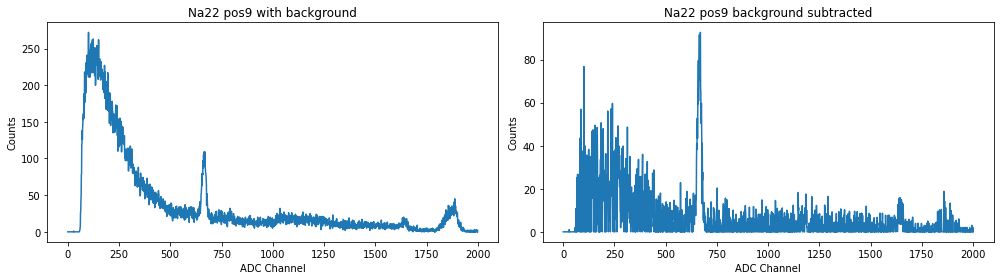

In [81]:
for key in na22d:
    range_na22 = (na22d[key]["channels"] > 0) & (na22d[key]["channels"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22d[key]["channels"][range_na22], na22d[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("ADC Channel")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22d[key]["channels"][range_na22], na22d[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("ADC Channel")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

#### 18/03

In [82]:
for key in na22m:
    counts_bg_na22 = bg["m"]["counts"] * (na22m[key]["time"] / bg["m"]["time"])
    na22m[key]["netcounts"] = na22m[key]["counts"] - counts_bg_na22
    na22m[key]["netcounts"][na22m[key]["netcounts"] < 0] = 0

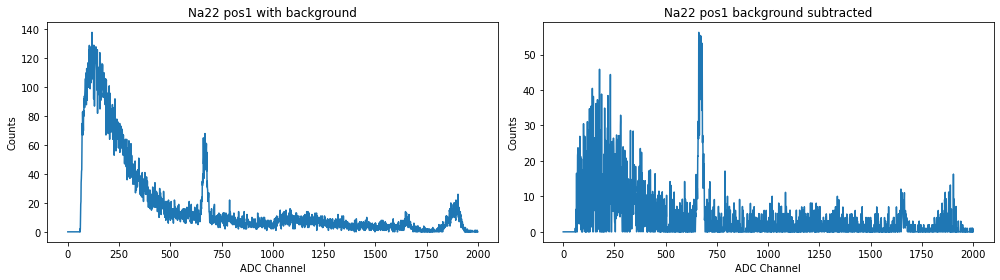

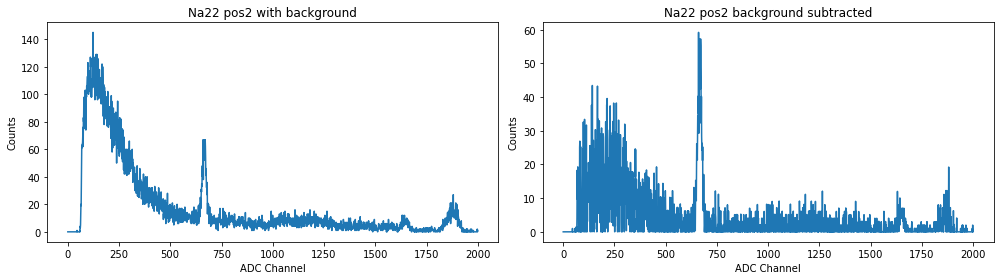

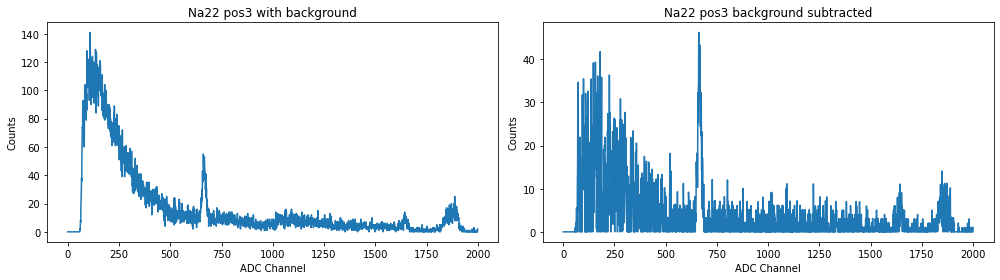

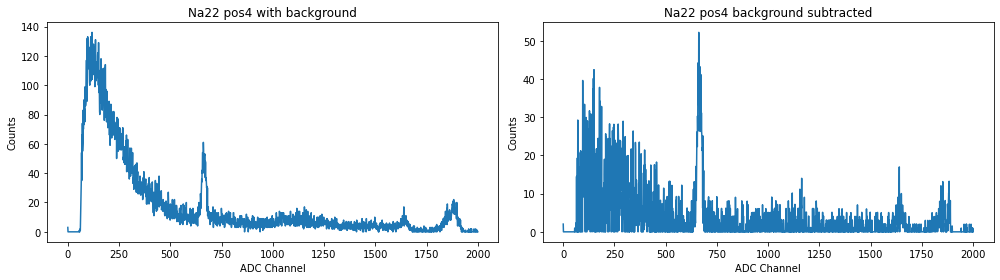

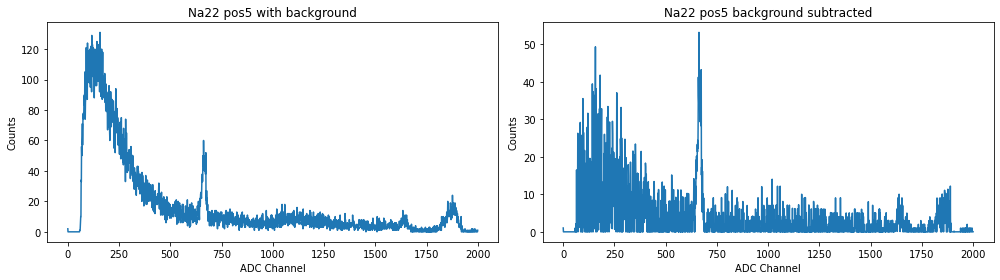

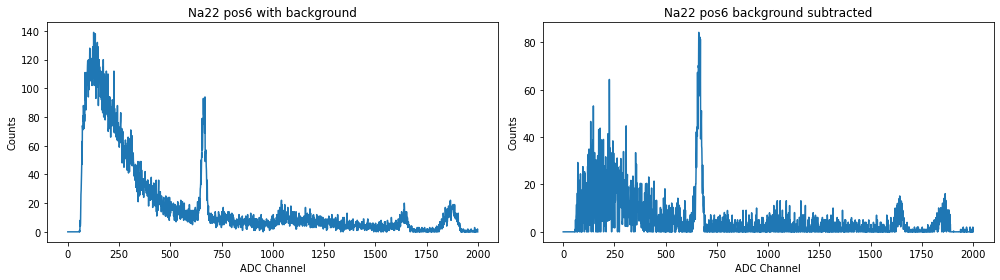

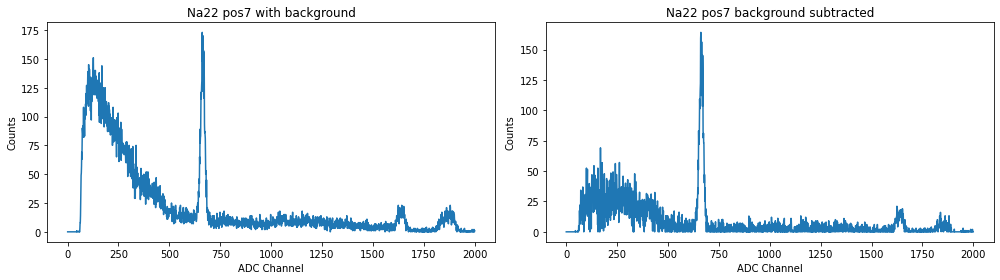

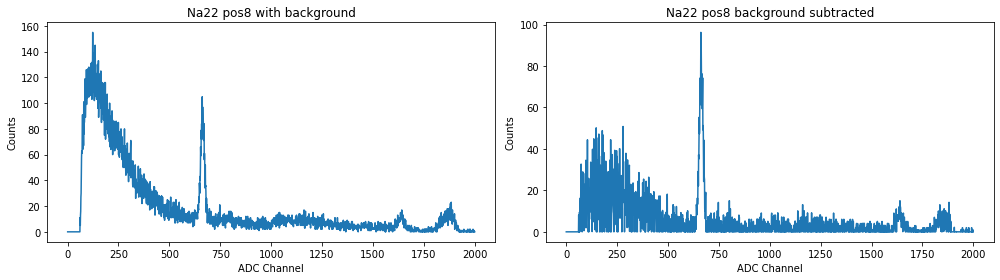

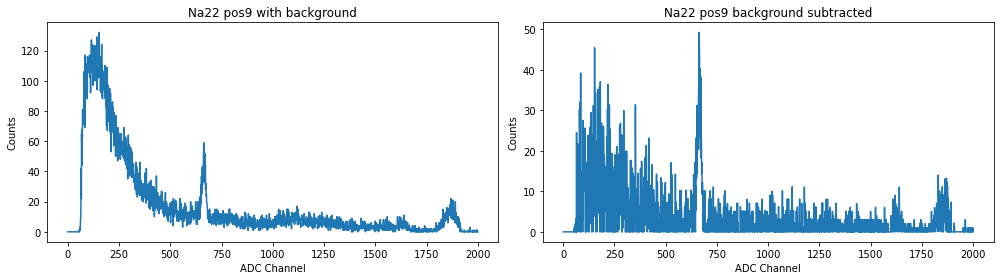

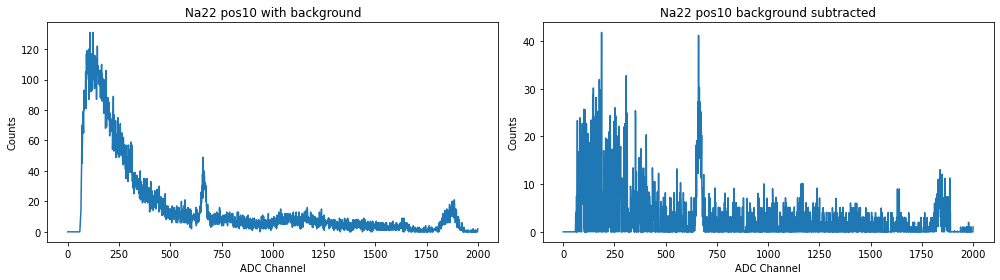

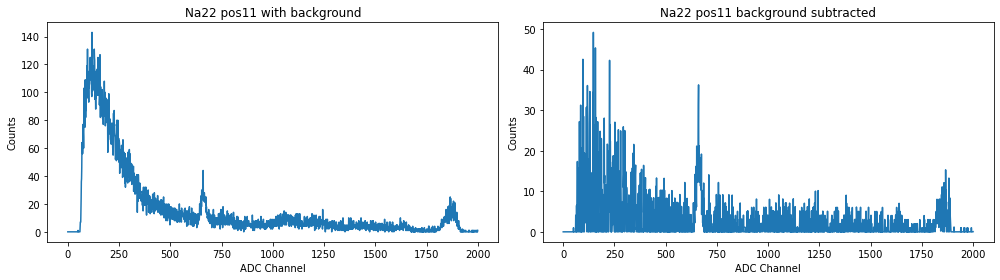

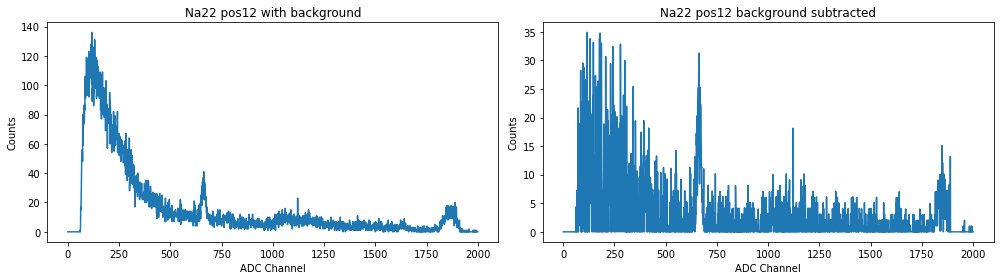

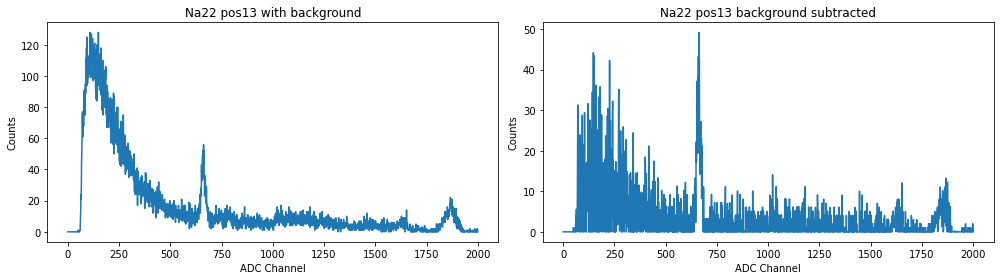

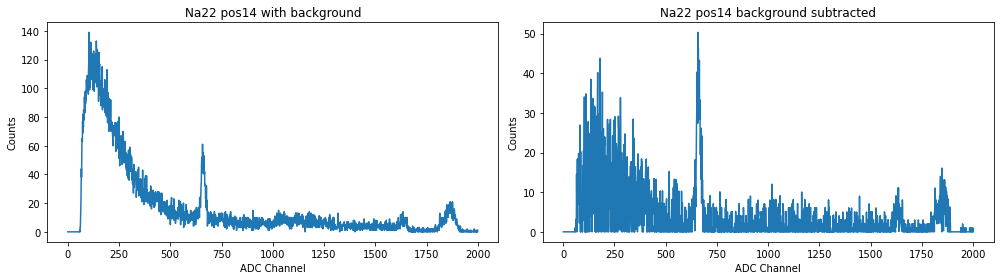

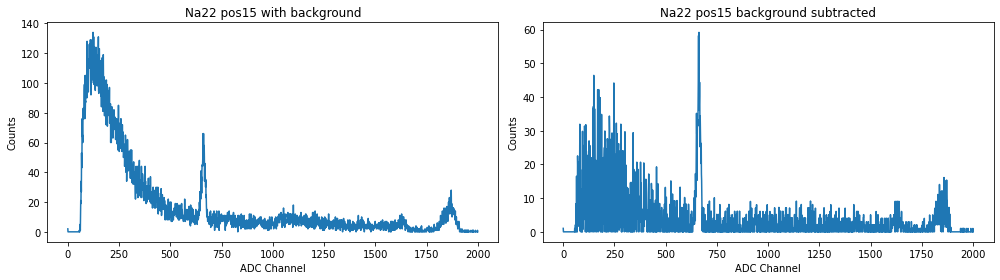

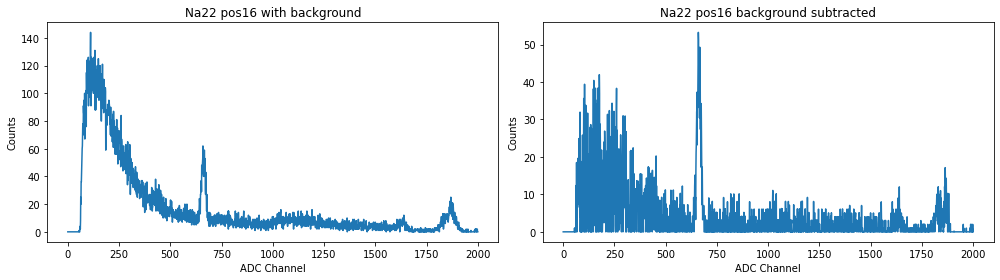

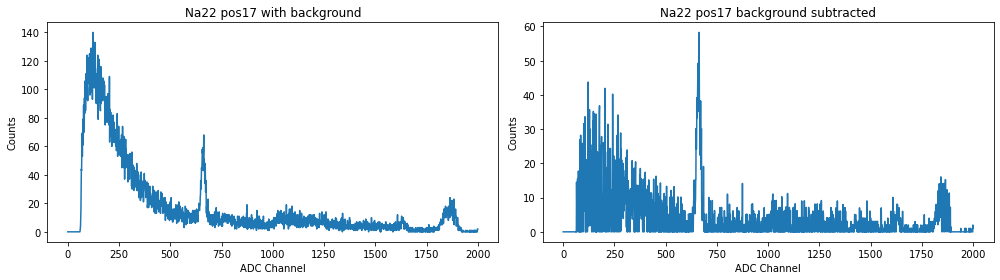

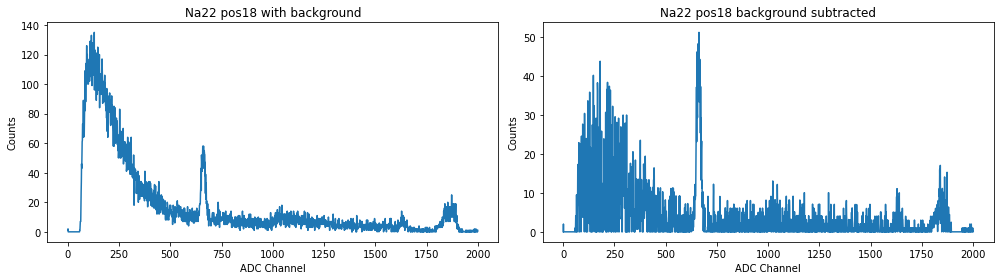

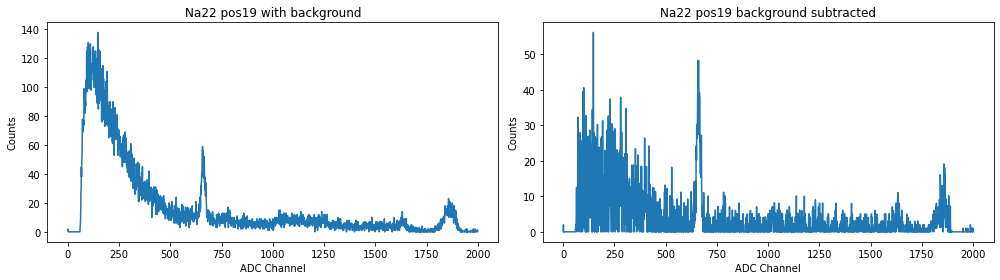

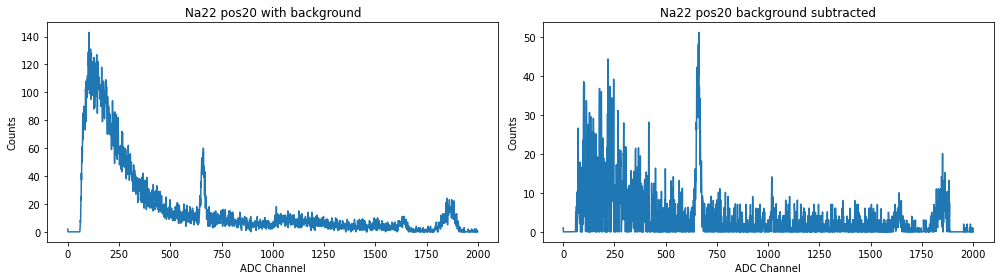

In [83]:
for key in na22m:
    range_na22 = (na22m[key]["channels"] > 0) & (na22m[key]["channels"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22m[key]["channels"][range_na22], na22m[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("ADC Channel")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22m[key]["channels"][range_na22], na22m[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("ADC Channel")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    display(plt.gcf())  
    plt.close()

---

# Statistical errors

#### 17/12

In [84]:
for key in na22d:
    na22d[key]["sigma_counts"] = np.sqrt(na22d[key]["counts"] + (na22d[key]["time"] / bg["d"]["time"])**2 * bg["d"]["counts"])
    na22d[key]["sigma_counts"][na22d[key]["sigma_counts"] == 0] = 1

#### 18/03

In [85]:
for key in na22m:
    na22m[key]["sigma_counts"] = np.sqrt(na22m[key]["counts"] + (na22m[key]["time"] / bg["d"]["time"])**2 * bg["d"]["counts"])
    na22m[key]["sigma_counts"][na22m[key]["sigma_counts"] == 0] = 1

---

# Peak information

In [86]:
activity = 36200
halflife = 2.6
d0 = date(2010, 6, 1)
d1 = date(2026, 3, 4)
delta_t = (d1-d0).total_seconds()
current_a = activity*np.exp((-np.log(2)*delta_t)/(halflife*365.25*24*3600)) 
print(current_a)

542.5358499132185


In [87]:
energy_na22 = 511
channel_na22 = 665
intensity_na22 = 179.8
activity_na22 = 542.5358499132185

---

# Fit peaks

In [88]:
def model(x, A, mu, sigma, B, c):
    return (A / (np.sqrt(2*np.pi)*sigma)) * np.exp(-(x-mu)**2/(2*sigma**2)) + B*x + c

#### 17/12

Counts (A): 5416.85 ± 103.51
Mean (mu): 667.75 ± 0.18
Sigma: 9.43 ± 0.17
Background linear (B): -0.0856 ± 0.0244
Background constant (c): 65.01 ± 16.27

Reduced chi²: 0.8551992736
P-value: 0.841748208782199


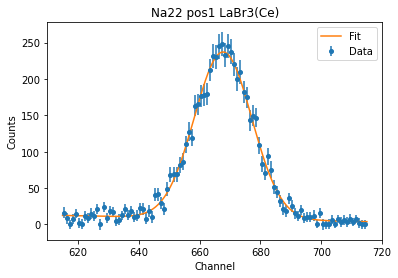

Counts (A): 2377.99 ± 87.81
Mean (mu): 667.69 ± 0.35
Sigma: 9.95 ± 0.35
Background linear (B): -0.0444 ± 0.0236
Background constant (c): 34.21 ± 15.72

Reduced chi²: 0.7975822775
P-value: 0.926874686024431


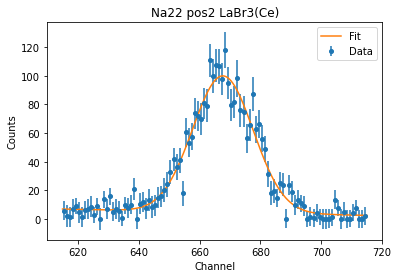

Counts (A): 1283.61 ± 81.55
Mean (mu): 666.93 ± 0.57
Sigma: 9.82 ± 0.60
Background linear (B): -0.0238 ± 0.0241
Background constant (c): 20.30 ± 16.03

Reduced chi²: 0.8149647918
P-value: 0.905662046249977


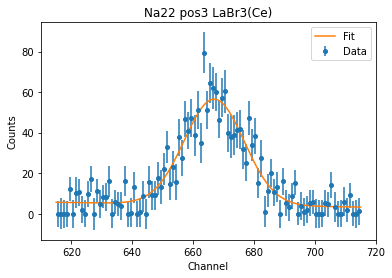

Counts (A): 2070.15 ± 82.97
Mean (mu): 666.53 ± 0.38
Sigma: 9.85 ± 0.38
Background linear (B): -0.0456 ± 0.0226
Background constant (c): 34.02 ± 15.06

Reduced chi²: 0.5772830027
P-value: 0.999685829788775


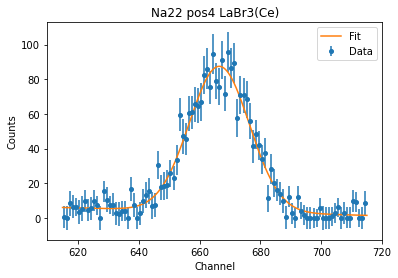

Counts (A): 1824.24 ± 79.91
Mean (mu): 666.68 ± 0.40
Sigma: 9.68 ± 0.41
Background linear (B): -0.0420 ± 0.0224
Background constant (c): 31.76 ± 14.93

Reduced chi²: 0.6782445952
P-value: 0.993120138990653


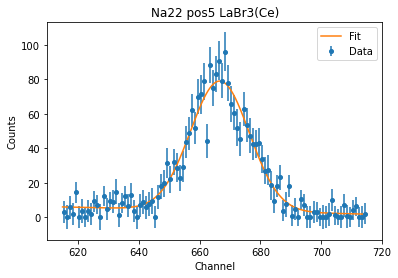

Counts (A): 3745.26 ± 93.00
Mean (mu): 665.83 ± 0.24
Sigma: 9.62 ± 0.23
Background linear (B): -0.0766 ± 0.0230
Background constant (c): 56.48 ± 15.38

Reduced chi²: 0.9294001881
P-value: 0.673588078516431


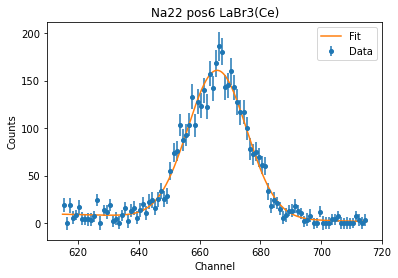

Counts (A): 1413.45 ± 75.47
Mean (mu): 665.44 ± 0.47
Sigma: 9.26 ± 0.48
Background linear (B): -0.0441 ± 0.0227
Background constant (c): 33.59 ± 15.12

Reduced chi²: 0.7362304430
P-value: 0.974911143686028


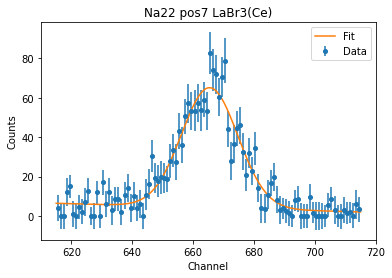

Counts (A): 2884.98 ± 84.70
Mean (mu): 664.71 ± 0.27
Sigma: 9.23 ± 0.26
Background linear (B): -0.0312 ± 0.0223
Background constant (c): 25.19 ± 14.87

Reduced chi²: 0.8815827605
P-value: 0.788692293901731


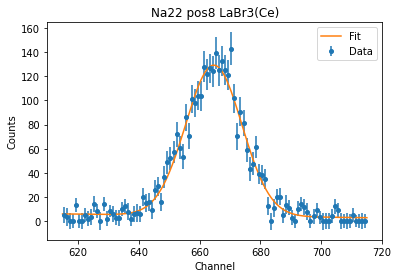

Counts (A): 1820.77 ± 75.93
Mean (mu): 664.91 ± 0.36
Sigma: 8.84 ± 0.36
Background linear (B): -0.0553 ± 0.0224
Background constant (c): 40.90 ± 14.96

Reduced chi²: 0.5682869306
P-value: 0.999775701631720


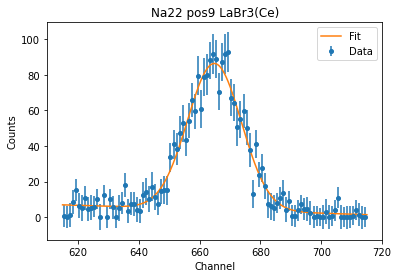

[5416.854993399299, 2377.988341187515, 1283.6075702950964, 2070.1490990975462, 1824.2397991076693, 3745.2623591740053, 1413.45107815868, 2884.983145786505, 1820.7669923499095]


In [138]:
counts_listd = []
countserr_listd = []
mu_listd = []
muerr_listd = []
sigma_listd = []
sigmaerr_listd = []

for key in na22d:
    peak_channel_guess = channel_na22
    fit_width = 50
    
    xmin = peak_channel_guess - fit_width
    xmax = peak_channel_guess + fit_width
    
    mask = (na22d[key]["channels"] >= xmin) & (na22d[key]["channels"] <= xmax)
    x = na22d[key]["channels"][mask]
    y = na22d[key]["netcounts"][mask]
    
    A_guess = np.sum(y)
    mu_guess = peak_channel_guess
    sigma_guess = 10
    B_guess = 0
    c_guess = np.min(y)
    
    p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]
    
    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=p0,
        sigma=na22d[key]["sigma_counts"][mask],
        absolute_sigma=True
    )
    
    perr = np.sqrt(np.diag(pcov))
    A, mu, sigma, B, c = popt
    A_err, mu_err, sigma_err, B_err, c_err = perr
    y_fit = model(x, *popt)
    
    chi2_val = np.sum(((y - y_fit)/na22d[key]["sigma_counts"][mask])**2)
    ndof = len(x) - len(popt)
    chi2_red = chi2_val / ndof
    p_value = 1 - chi2.cdf(chi2_val, ndof)
    
    print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
    print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
    print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")
    print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
    print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")
    print()
    print(f"Reduced chi²: {chi2_red:.10f}")
    print(f"P-value: {p_value:.15f}")
    
    counts_listd.append(A)
    countserr_listd.append(A_err)
    mu_listd.append(mu)
    muerr_listd.append(mu_err)
    sigma_listd.append(sigma)
    sigmaerr_listd.append(sigma_err)
    
    x_plot = np.linspace(xmin, xmax, 1000)
    plt.errorbar(x, y, yerr=na22d[key]["sigma_counts"][mask], fmt='o', label="Data", markersize=4)
    plt.plot(x_plot, model(x_plot, *popt), label="Fit")
    plt.xlabel("Channel")
    plt.ylabel("Counts")
    plt.title(f"Na22 pos{key} LaBr3(Ce)")
    plt.legend()
    plt.show()


print(counts_listd)

In [139]:
print(len(counts_listd))

9


#### 18/03

Counts (A): 1142.71 ± 49.68
Mean (mu): 669.96 ± 0.41
Sigma: 9.29 ± 0.40
Background linear (B): -0.0022 ± 0.0100
Background constant (c): 3.49 ± 6.62

Reduced chi²: 0.7944578852
P-value: 0.949036313136678


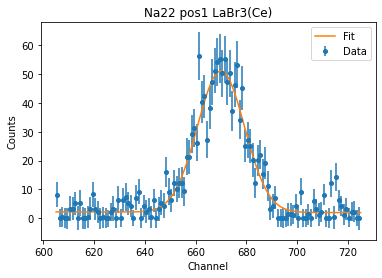

Counts (A): 1187.88 ± 50.81
Mean (mu): 665.73 ± 0.43
Sigma: 9.93 ± 0.41
Background linear (B): -0.0081 ± 0.0097
Background constant (c): 6.94 ± 6.48

Reduced chi²: 0.7020533434
P-value: 0.993576440344568


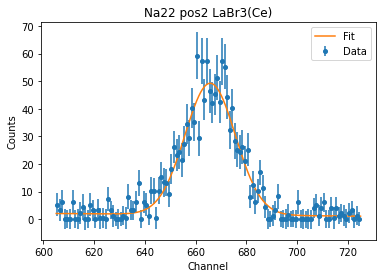

Counts (A): 764.38 ± 42.96
Mean (mu): 665.13 ± 0.50
Sigma: 8.66 ± 0.48
Background linear (B): -0.0084 ± 0.0094
Background constant (c): 7.19 ± 6.27

Reduced chi²: 0.5936542893
P-value: 0.999836366945983


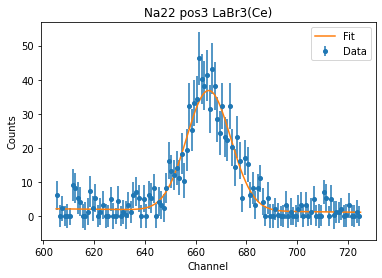

Counts (A): 1023.85 ± 49.86
Mean (mu): 664.52 ± 0.49
Sigma: 10.09 ± 0.47
Background linear (B): 0.0080 ± 0.0098
Background constant (c): -3.63 ± 6.55

Reduced chi²: 0.8601149861
P-value: 0.857725022432481


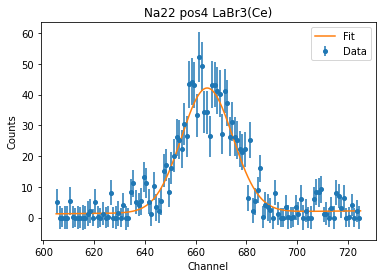

Counts (A): 837.91 ± 46.36
Mean (mu): 663.69 ± 0.53
Sigma: 9.49 ± 0.52
Background linear (B): -0.0062 ± 0.0099
Background constant (c): 6.10 ± 6.64

Reduced chi²: 0.6692099022
P-value: 0.997518643781373


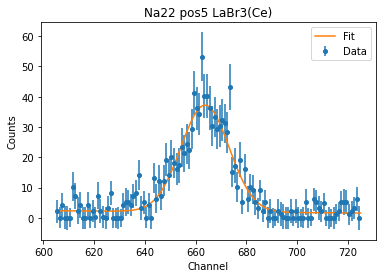

Counts (A): 1741.30 ± 57.54
Mean (mu): 663.36 ± 0.34
Sigma: 10.20 ± 0.32
Background linear (B): -0.0117 ± 0.0100
Background constant (c): 9.76 ± 6.76

Reduced chi²: 0.7761880717
P-value: 0.963953385764315


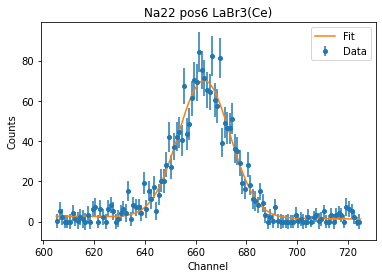

Counts (A): 3508.72 ± 71.85
Mean (mu): 663.57 ± 0.21
Sigma: 9.98 ± 0.19
Background linear (B): -0.0226 ± 0.0103
Background constant (c): 17.62 ± 6.94

Reduced chi²: 1.0437644756
P-value: 0.355334273837780


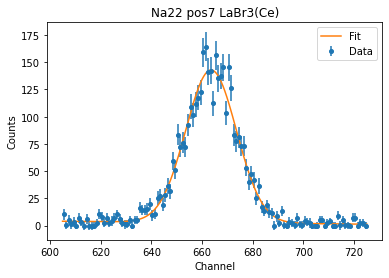

Counts (A): 1803.87 ± 56.84
Mean (mu): 663.09 ± 0.31
Sigma: 9.64 ± 0.29
Background linear (B): -0.0080 ± 0.0099
Background constant (c): 7.38 ± 6.66

Reduced chi²: 0.7552151055
P-value: 0.976640534589991


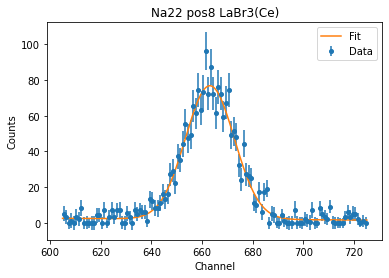

Counts (A): 788.90 ± 45.38
Mean (mu): 663.62 ± 0.53
Sigma: 9.08 ± 0.52
Background linear (B): -0.0120 ± 0.0100
Background constant (c): 10.21 ± 6.73

Reduced chi²: 0.9329209725
P-value: 0.683057073517454


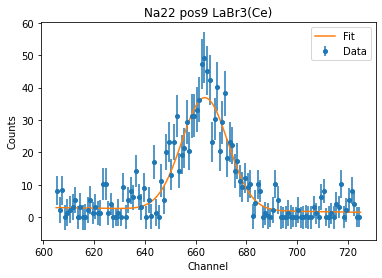

Counts (A): 568.00 ± 43.14
Mean (mu): 663.15 ± 0.74
Sigma: 9.82 ± 0.73
Background linear (B): -0.0003 ± 0.0095
Background constant (c): 1.25 ± 6.40

Reduced chi²: 0.5285715461
P-value: 0.999992378303347


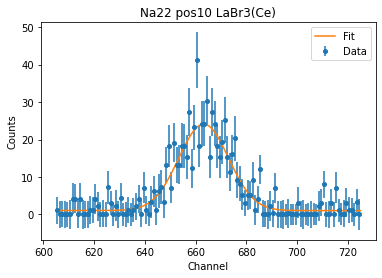

Counts (A): 477.73 ± 45.23
Mean (mu): 661.44 ± 0.98
Sigma: 10.91 ± 1.01
Background linear (B): 0.0065 ± 0.0096
Background constant (c): -3.14 ± 6.43

Reduced chi²: 0.6488093991
P-value: 0.998713534112426


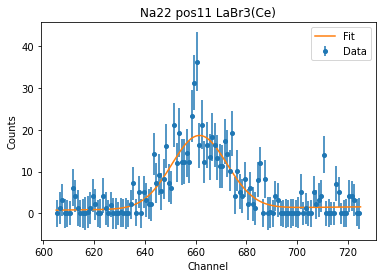

Counts (A): 459.21 ± 41.64
Mean (mu): 662.86 ± 0.86
Sigma: 9.63 ± 0.86
Background linear (B): -0.0016 ± 0.0097
Background constant (c): 2.51 ± 6.47

Reduced chi²: 0.6660248175
P-value: 0.997752740278348


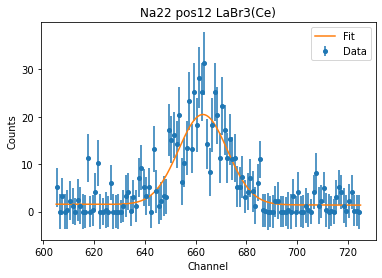

Counts (A): 795.66 ± 47.45
Mean (mu): 661.62 ± 0.61
Sigma: 10.35 ± 0.61
Background linear (B): 0.0013 ± 0.0097
Background constant (c): 0.42 ± 6.51

Reduced chi²: 0.7697511312
P-value: 0.968313217834581


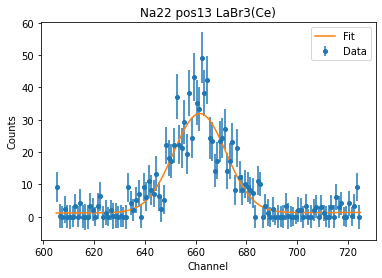

Counts (A): 886.10 ± 47.10
Mean (mu): 660.42 ± 0.51
Sigma: 9.51 ± 0.49
Background linear (B): -0.0025 ± 0.0098
Background constant (c): 3.50 ± 6.56

Reduced chi²: 0.7798355362
P-value: 0.961284487432399


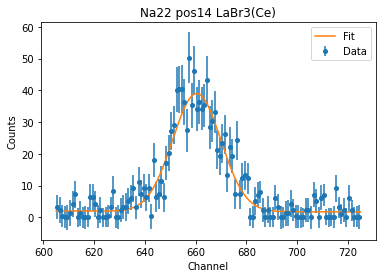

Counts (A): 944.86 ± 46.60
Mean (mu): 660.99 ± 0.46
Sigma: 9.19 ± 0.44
Background linear (B): -0.0036 ± 0.0095
Background constant (c): 3.76 ± 6.41

Reduced chi²: 0.6968211523
P-value: 0.994433373484078


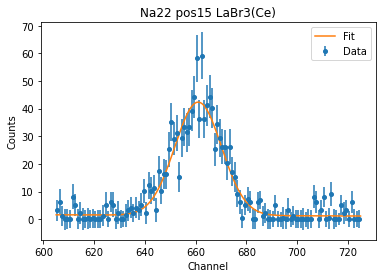

Counts (A): 1033.27 ± 48.64
Mean (mu): 661.54 ± 0.46
Sigma: 9.61 ± 0.44
Background linear (B): -0.0005 ± 0.0098
Background constant (c): 1.75 ± 6.56

Reduced chi²: 0.5950527474
P-value: 0.999826614393231


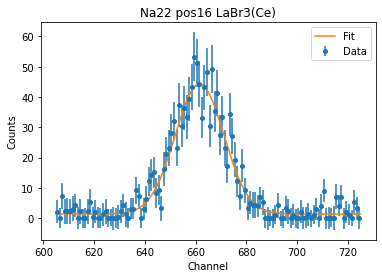

Counts (A): 1021.76 ± 48.59
Mean (mu): 660.39 ± 0.46
Sigma: 9.51 ± 0.44
Background linear (B): -0.0062 ± 0.0098
Background constant (c): 5.80 ± 6.61

Reduced chi²: 0.6555699405
P-value: 0.998391197138320


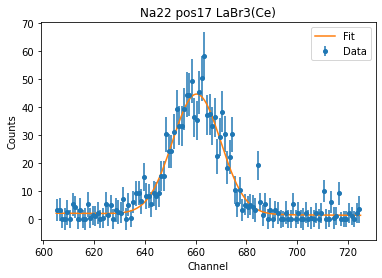

Counts (A): 1054.07 ± 49.32
Mean (mu): 661.19 ± 0.46
Sigma: 9.72 ± 0.44
Background linear (B): -0.0065 ± 0.0098
Background constant (c): 5.73 ± 6.60

Reduced chi²: 0.5262921883
P-value: 0.999993252237608


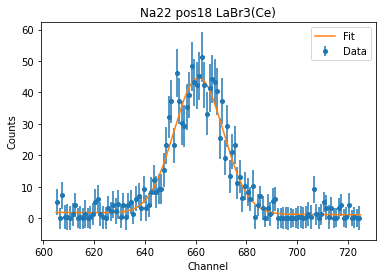

Counts (A): 860.46 ± 46.19
Mean (mu): 660.52 ± 0.50
Sigma: 9.22 ± 0.48
Background linear (B): -0.0080 ± 0.0097
Background constant (c): 6.99 ± 6.58

Reduced chi²: 0.6686890315
P-value: 0.997558320999731


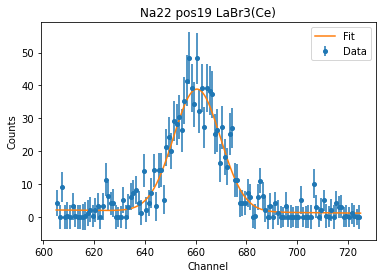

Counts (A): 853.62 ± 45.13
Mean (mu): 659.39 ± 0.47
Sigma: 8.72 ± 0.46
Background linear (B): 0.0032 ± 0.0098
Background constant (c): -0.30 ± 6.62

Reduced chi²: 0.7000987723
P-value: 0.993908819456158


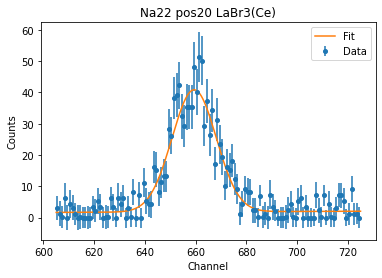

[1142.7127520653435, 1187.8797947486057, 764.3796558075371, 1023.846055689647, 837.9094746921614, 1741.300929388599, 3508.723499350394, 1803.8748123716562, 788.9008052352485, 567.9973548699019, 477.72961228414886, 459.20815332649886, 795.6597386174419, 886.1006928445958, 944.8647472991576, 1033.2693993359148, 1021.7648724343413, 1054.0747758549069, 860.4630925341817, 853.6218360409174]


In [140]:
counts_listm = []
countserr_listm = []
mu_listm = []
muerr_listm = []
sigma_listm = []
sigmaerr_listm = []

for key in na22m:
    peak_channel_guess = channel_na22
    fit_width = 60
    
    xmin = peak_channel_guess - fit_width
    xmax = peak_channel_guess + fit_width
    
    mask = (na22m[key]["channels"] >= xmin) & (na22m[key]["channels"] <= xmax)
    x = na22m[key]["channels"][mask]
    y = na22m[key]["netcounts"][mask]
    
    A_guess = np.sum(y)
    mu_guess = peak_channel_guess
    sigma_guess = 10
    B_guess = 0
    c_guess = np.min(y)
    
    p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]
    
    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=p0,
        sigma=na22m[key]["sigma_counts"][mask],
        absolute_sigma=True
    )
    
    perr = np.sqrt(np.diag(pcov))
    A, mu, sigma, B, c = popt
    A_err, mu_err, sigma_err, B_err, c_err = perr
    y_fit = model(x, *popt)
    
    chi2_val = np.sum(((y - y_fit)/na22m[key]["sigma_counts"][mask])**2)
    ndof = len(x) - len(popt)
    chi2_red = chi2_val / ndof
    p_value = 1 - chi2.cdf(chi2_val, ndof)
    
    print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
    print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
    print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")
    print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
    print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")
    print()
    print(f"Reduced chi²: {chi2_red:.10f}")
    print(f"P-value: {p_value:.15f}")
    
    counts_listm.append(A)
    countserr_listm.append(A_err)
    mu_listm.append(mu)
    muerr_listm.append(mu_err)
    sigma_listm.append(sigma)
    sigmaerr_listm.append(sigma_err)
    
    x_plot = np.linspace(xmin, xmax, 1000)
    plt.errorbar(x, y, yerr=na22m[key]["sigma_counts"][mask], fmt='o', label="Data", markersize=4)
    plt.plot(x_plot, model(x_plot, *popt), label="Fit")
    plt.xlabel("Channel")
    plt.ylabel("Counts")
    plt.title(f"Na22 pos{key} LaBr3(Ce)")
    plt.legend()
    plt.show()

print(counts_listm)

In [141]:
print(len(counts_listm))

20


---

# Absolute efficiency

#### 17/12

1. (4,1): 4.2cm from LaBr3(Ce), 10.2cm from CeBr3 
2. (4,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3
3. (4,7): 10.2cm from LaBr3(Ce), 4.2cm from CeBr3
4. (1,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
5. (7,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
6. (4,2): 5.2cm from LaBr3(Ce), 9.2cm from CeBr3 
7. (4,6): 9.2cm from LaBr3(Ce), 5.2cm from CeBr3 
8. (4,3): 6.2cm from LaBr3(Ce), 8.2cm from CeBr3 
9. (4,5): 8.2cm from LaBr3(Ce), 6.2cm from CeBr3 

In [159]:
translationalx = np.array([4.2, 7.2, 10.2, 7.8, 7.8, 5.2, 9.2, 6.2, 8.2])

In [160]:
times = np.array([na22d[key]["time"] for key in na22d])
absolute_effd = counts_listd/(activity_na22*times*(intensity_na22/100))

In [161]:
#error on efficiency
rel_counts = np.array(countserr_listd) / np.array(counts_listd)
abs_eff_errd = absolute_effd * np.sqrt(rel_counts**2)

In [162]:
def inv_square_model(x, A, B, C):
    return A / (x + B)**2 + C

A = 3.5896e-01 ± 9.5122e-02
B = 2.1946e+00 ± 7.2741e-01
C = -5.0805e-04 ± 4.1931e-04


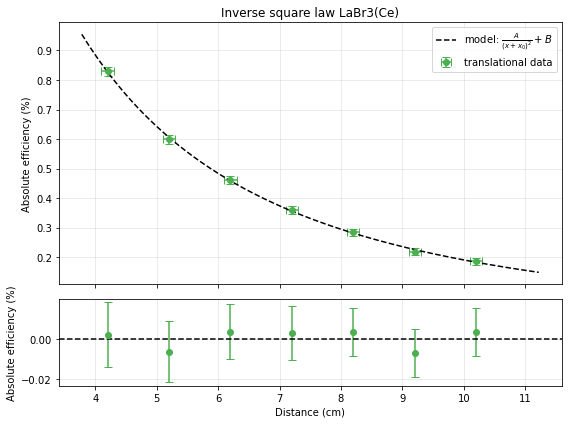

Reduced chi²: 0.742
P-value: 0.6156


In [194]:
# Fit the resolution
p0 = [1,0,0]
popt, pcov = curve_fit(
    inv_square_model,
    translationalx,
    absolute_effd,
    sigma=abs_eff_errd,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))
A_eff, B_eff, C_eff = popt

# Residuals
residuals = absolute_effd - inv_square_model(translationalx, *popt)

# --- Compute reduced chi² and p-value ---
chi2_val = np.sum((residuals / abs_eff_errd)**2)
ndof = len(translationalx) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

# --- Plotting ---
fig, (ax_main, ax_resid) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios':[3,1]}, figsize=(8,6))

print(f"A = {A_eff:.4e} ± {perr[0]:.4e}")
print(f"B = {B_eff:.4e} ± {perr[1]:.4e}")
print(f"C = {C_eff:.4e} ± {perr[2]:.4e}")

# --- Main plot ---
E_plot = np.linspace(min(translationalx)*0.9, max(translationalx)*1.1, 500)

ax_main.errorbar(translationalx[[0,1,2,5,6,7,8]], absolute_effd[[0,1,2,5,6,7,8]]*100, xerr =0.1, yerr=abs_eff_errd[[0,1,2,5,6,7,8]]*100, fmt='o', color='#4CAF50', label='translational data', capsize=4)
ax_main.plot(E_plot, inv_square_model(E_plot, *popt)*100, 'k--', label=r'model: $\frac{A}{(x + x_0)^2} + B$')
ax_main.set_ylabel("Absolute efficiency (%)")
ax_main.set_title("Inverse square law LaBr3(Ce)")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

ax_resid.errorbar(translationalx[[0,1,2,5,6,7,8]], residuals[[0,1,2,5,6,7,8]]*100, yerr=abs_eff_errd[[0,1,2,5,6,7,8]]*100, fmt='o', color='#4CAF50', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Distance (cm)")
ax_resid.set_ylabel("Absolute efficiency (%)")
ax_resid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

#### 18/03

- translational: 7 x 7 holes
- rotational: 45 degree rotations

1. (4,4)(not aligned yet)

##### turn casing
2. (4,4) 0° (casing line -> LaBr3(Ce))
3. (4,4) 90°
4. (4,4) 180°
5. (4,4) 270°

##### rotational measurements
6. (7,1) 0° (casing line -> CeBr3)
7. 45° (source closest to LaBr3(Ce))
8. 90°
9. 135° (source in middle (wall side))
10. 180°
11. 225° (source closest to CeBr3)
12. 270°
13. 315°

##### translational measurements (middle y-axis)
14. (7,4)(bottom middle hole)(casing line -> CeBr3)
15. (6,4)
16. (5,4)
17. (4,4)(middle hole)
18. (3,4)
19. (2,4)
20. (1,4)

In [195]:
translationaly = np.array([-3,-2,-1,0,1,2,3]) #14,15,16,17,18,19,20
rotational = np.array([0,45,90,135,180,225,270,315]) #6,7,8,9,10,11,12,13
casing = np.array([0]) #2,3,4,5

In [196]:
times = np.array([na22m[key]["time"] for key in na22m])
absolute_effm = counts_listm/(activity_na22*times*(intensity_na22/100))

In [197]:
#error on efficiency
rel_counts = np.array(countserr_listm) / np.array(counts_listm)
abs_eff_errm = absolute_effm * np.sqrt(rel_counts**2)

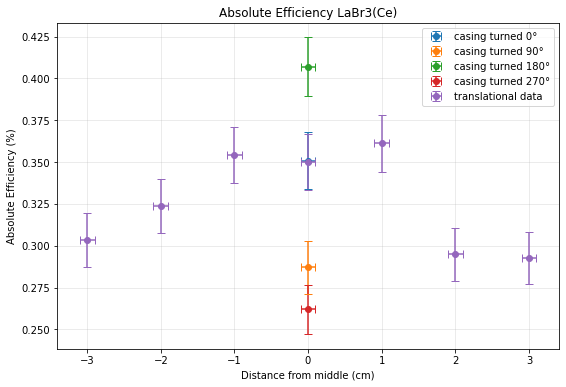

In [198]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(casing, absolute_effm[3]*100, xerr=0.1, yerr=abs_eff_errm[3]*100, fmt='o', label='casing turned 0°', capsize=4)
plt.errorbar(casing, absolute_effm[4]*100, xerr=0.1, yerr=abs_eff_errm[4]*100, fmt='o', label='casing turned 90°', capsize=4)
plt.errorbar(casing, absolute_effm[1]*100, xerr=0.1, yerr=abs_eff_errm[1]*100, fmt='o', label='casing turned 180°', capsize=4)
plt.errorbar(casing, absolute_effm[2]*100, xerr=0.1, yerr=abs_eff_errm[2]*100, fmt='o', label='casing turned 270°', capsize=4)
plt.errorbar(translationaly, absolute_effm[13:20]*100, xerr=0.1, yerr=abs_eff_errm[13:20]*100, fmt='o', label='translational data', capsize=4)
plt.xlabel("Distance from middle (cm)")
plt.ylabel("Absolute Efficiency (%)")
plt.title("Absolute Efficiency LaBr3(Ce)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

- x = distance between source and middle circle (7.2 cm)
- r = distance from source to middle circle (radius)(3 cm)
$d(\theta) = \sqrt{x^2+r^2-2xr\cos(\theta - 45°)}$

In [205]:
def inv_square_model_degrees(x, A, B, C):
    d = np.sqrt(7.2**2 + 3**2 - 2*7.2*3*np.cos(np.radians(x-45)))
    return A / (d + B)**2 + C

A = 1.1419e-01 ± 1.7423e-02
B = -1.0954e+00 ± 2.2829e-01
C = 1.8717e-04 ± 2.0627e-04


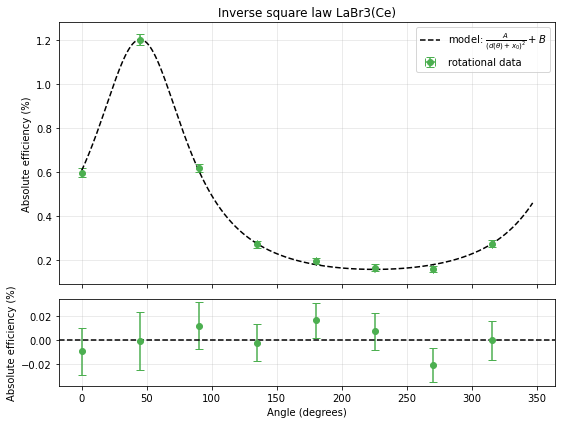

Reduced chi²: 0.843
P-value: 0.5190


In [206]:
# Fit the resolution
p0 = [1,0,0]
popt, pcov = curve_fit(
    inv_square_model_degrees,
    rotational,
    absolute_effm[5:13],
    sigma=abs_eff_errm[5:13],
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))
A_eff, B_eff, C_eff = popt

# Residuals
residuals = absolute_effm[5:13] - inv_square_model_degrees(rotational, *popt)

# --- Compute reduced chi² and p-value ---
chi2_val = np.sum((residuals / abs_eff_errm[5:13])**2)
ndof = len(rotational) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

# --- Plotting ---
fig, (ax_main, ax_resid) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios':[3,1]}, figsize=(8,6))

print(f"A = {A_eff:.4e} ± {perr[0]:.4e}")
print(f"B = {B_eff:.4e} ± {perr[1]:.4e}")
print(f"C = {C_eff:.4e} ± {perr[2]:.4e}")

# --- Main plot ---
E_plot = np.linspace(min(rotational)*0.9, max(rotational)*1.1, 500)

ax_main.errorbar(rotational, absolute_effm[5:13]*100, xerr =0.1, yerr=abs_eff_errm[5:13]*100, fmt='o', color='#4CAF50', label='rotational data', capsize=4)
ax_main.plot(E_plot, inv_square_model_degrees(E_plot, *popt)*100, 'k--', label=r'model: $\frac{A}{(d(\theta) + x_0)^2} + B$')
ax_main.set_ylabel("Absolute efficiency (%)")
ax_main.set_title("Inverse square law LaBr3(Ce)")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

ax_resid.errorbar(rotational, residuals*100, yerr=abs_eff_errm[5:13]*100, fmt='o', color='#4CAF50', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Angle (degrees)")
ax_resid.set_ylabel("Absolute efficiency (%)")
ax_resid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")